# Backtesting: O Teste de Estresse do Modelo de xG

Neste script, pegamos o motor de xG (Poisson + EMA) construído na Fase 1 e o submetemos a uma simulação histórica (Backtesting) da temporada 23/24 da Premier League.

**O grande diferencial deste código:** Em vez de apostar em qualquer "valor" encontrado, implementamos um **Coeficiente de Segurança (Edge de 10%)**. O robô só arrisca capital se o erro da casa de apostas for superior a 10%, protegendo a banca da variância do esporte. Além disso, restringimos a busca por valor apenas aos Mandantes, mitigando a fraqueza matemática do Poisson ao calcular Empates.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Carregando os dados e preparando o caixa financeiro
url = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
df = pd.read_csv(url)
colunas_importantes = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'B365H']
df_backtest = df[colunas_importantes].copy()

banca_inicial = 1000.00
valor_aposta = 10.00

### Loop Iterativo
O código abaixo varre a temporada jogo a jogo, garantindo que o algoritmo só enxergue o passado para calcular a Odd Justa.

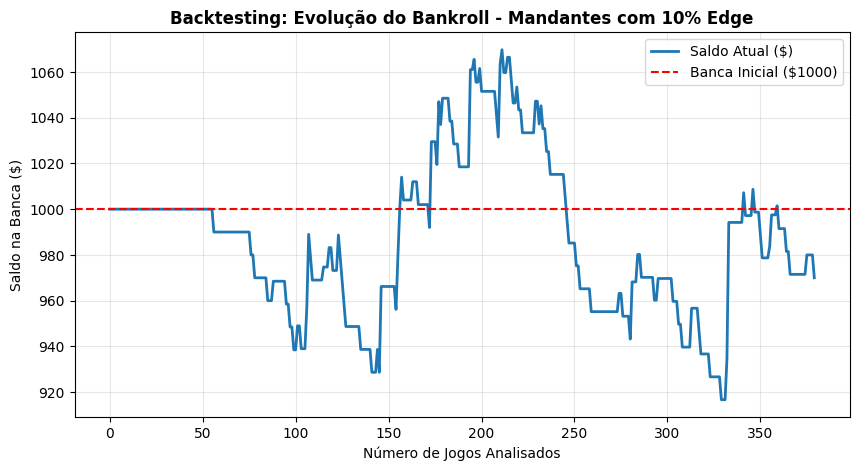

Total de Entradas: 103 | Win Rate: 36.89% | ROI: -2.91%


In [2]:
apostas_feitas = 0
apostas_ganhas = 0
banca_atual = banca_inicial
historico_banca = [] 
margem_seguranca = 1.10 # Edge de 10%

for index, jogo in df_backtest.iterrows():
    if index < 50: # Período de aquecimento da EMA
        historico_banca.append(banca_atual)
        continue 
        
    time_casa = jogo['HomeTeam']
    time_fora = jogo['AwayTeam']
    
    df_passado = df.iloc[:index] # Evitando vazamento de dados do futuro
    media_liga_casa = df_passado['FTHG'].mean()
    media_liga_fora = df_passado['FTAG'].mean()
    
    df_hist_casa = df_passado[df_passado['HomeTeam'] == time_casa]
    df_hist_fora = df_passado[df_passado['AwayTeam'] == time_fora]
    
    if len(df_hist_casa) < 3 or len(df_hist_fora) < 3:
        historico_banca.append(banca_atual)
        continue
        
    ema_ataque_casa = df_hist_casa['FTHG'].ewm(span=5, adjust=False).mean().iloc[-1]
    ema_defesa_casa = df_hist_casa['FTAG'].ewm(span=5, adjust=False).mean().iloc[-1]
    ema_ataque_fora = df_hist_fora['FTAG'].ewm(span=5, adjust=False).mean().iloc[-1]
    ema_defesa_fora = df_hist_fora['FTHG'].ewm(span=5, adjust=False).mean().iloc[-1]
    
    forca_ataque_casa = ema_ataque_casa / media_liga_casa
    forca_defesa_casa = ema_defesa_casa / media_liga_fora
    forca_ataque_fora = ema_ataque_fora / media_liga_fora
    forca_defesa_fora = ema_defesa_fora / media_liga_casa
    
    xg_casa = forca_ataque_casa * forca_defesa_fora * media_liga_casa
    xg_fora = forca_ataque_fora * forca_defesa_casa * media_liga_fora
    
    prob_vitoria_casa = 0
    for i in range(6):
        for j in range(6):
            if i > j: prob_vitoria_casa += poisson.pmf(i, xg_casa) * poisson.pmf(j, xg_fora)
                
    if prob_vitoria_casa <= 0.01:
        historico_banca.append(banca_atual)
        continue
        
    odd_justa_casa = 100 / (prob_vitoria_casa * 100)
    odd_mercado = jogo['B365H']
    
    # GATILHO: Aposta se Mercado pagar 10% a mais que a Odd Justa
    if odd_mercado > (odd_justa_casa * margem_seguranca):
        apostas_feitas += 1
        if jogo['FTHG'] > jogo['FTAG']: 
            banca_atual += valor_aposta * (odd_mercado - 1)
            apostas_ganhas += 1
        else: 
            banca_atual -= valor_aposta
            
    historico_banca.append(banca_atual)

# --- PLOTAGEM DO GRÁFICO E RELATÓRIO ---
plt.figure(figsize=(10, 5))
plt.plot(historico_banca, color='#1f77b4', linewidth=2, label='Saldo Atual ($)')
plt.axhline(y=banca_inicial, color='red', linestyle='--', linewidth=1.5, label='Banca Inicial ($1000)')
plt.title('Backtesting: Evolução do Bankroll - Mandantes com 10% Edge', fontweight='bold')
plt.xlabel('Número de Jogos Analisados')
plt.ylabel('Saldo na Banca ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

win_rate = (apostas_ganhas / apostas_feitas) * 100 if apostas_feitas > 0 else 0
print(f"Total de Entradas: {apostas_feitas} | Win Rate: {win_rate:.2f}% | ROI: {((banca_atual-banca_inicial)/(apostas_feitas*valor_aposta))*100:.2f}%")